# **Inferential Analysis - part 2 (Correlation, Chi-Square, ANOVA)**

In [2]:
install.packages(c("ggplot2", "corrplot", "rstatix", "vcd", "lsr", "DescTools", "agricolae"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘fracdiff’, ‘timeDate’, ‘urca’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘proxy’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘zoo’, ‘rootSolve’, ‘e1071’, ‘lmom’, ‘car’, ‘colorspace’, ‘lmtest’, ‘mvtnorm’, ‘expm’, ‘Exact’, ‘gld’, ‘AlgDesign’




In [7]:
# Load the cleaned dataset
df = read.csv("/cleaned_data.csv")

In [8]:
# Making sure Respect_Category and Satisfaction_Category columns are already in it
str (df)
table(df$Respect_Category)
table(df$Satisfaction_Category)

'data.frame':	1470 obs. of  35 variables:
 $ Age                     : int  41 49 37 33 27 32 59 30 38 36 ...
 $ Attrition               : chr  "Yes" "No" "Yes" "No" ...
 $ BusinessTravel          : chr  "Travel_Rarely" "Travel_Frequently" "Travel_Rarely" "Travel_Frequently" ...
 $ DailyRate               : int  1102 279 1373 1392 591 1005 1324 1358 216 1299 ...
 $ Department              : chr  "Sales" "Research & Development" "Research & Development" "Research & Development" ...
 $ DistanceFromHome        : int  1 8 2 3 2 2 3 24 23 27 ...
 $ Education               : int  2 1 2 4 1 2 3 1 3 3 ...
 $ EducationField          : chr  "Life Sciences" "Life Sciences" "Other" "Life Sciences" ...
 $ EnvironmentSatisfaction : int  2 3 4 4 1 4 3 4 4 3 ...
 $ Gender                  : chr  "Female" "Male" "Male" "Female" ...
 $ HourlyRate              : int  94 61 92 56 40 79 81 67 44 94 ...
 $ JobInvolvement          : int  3 2 2 3 3 3 4 3 2 3 ...
 $ JobLevel                : int  2 2 1 1 1 1 1


High  Low 
 616  854 


High  Low 
 901  569 

## **Test 1 — Spearman Correlation**

 Here we are testing whether there is a linear relationship between Respect_Index (continuous) and JobSatisfaction (numeric scale 1–4)

*Our hypotheses*

*   H₀: There is no linear relationship between Respect_Index and JobSatisfaction (ρ = 0)
*   H₁: There is a significant positive linear relationship (ρ > 0) — one-tailed






In [9]:
# Checking normality first
# if both p-values > 0.05 --> indicates normality --> we use Pearson test
# if either p-value < 0.05 --> normality violated --> we switch to Spearman

shapiro.test(df$Respect_Index)
shapiro.test(df$JobSatisfaction)


	Shapiro-Wilk normality test

data:  df$Respect_Index
W = 0.986, p-value = 1.014e-10



	Shapiro-Wilk normality test

data:  df$JobSatisfaction
W = 0.8456, p-value < 2.2e-16


In [12]:
# Spearman Correlation Test

cor.test(df$Respect_Index, df$JobSatisfaction, method = "spearman", alternative = "greater")

Warning message in cor.test.default(df$Respect_Index, df$JobSatisfaction, method = "spearman", :
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  df$Respect_Index and df$JobSatisfaction
S = 543139001, p-value = 0.8396
alternative hypothesis: true rho is greater than 0
sample estimates:
        rho 
-0.02591277 


`geom_smooth()` using formula = 'y ~ x'


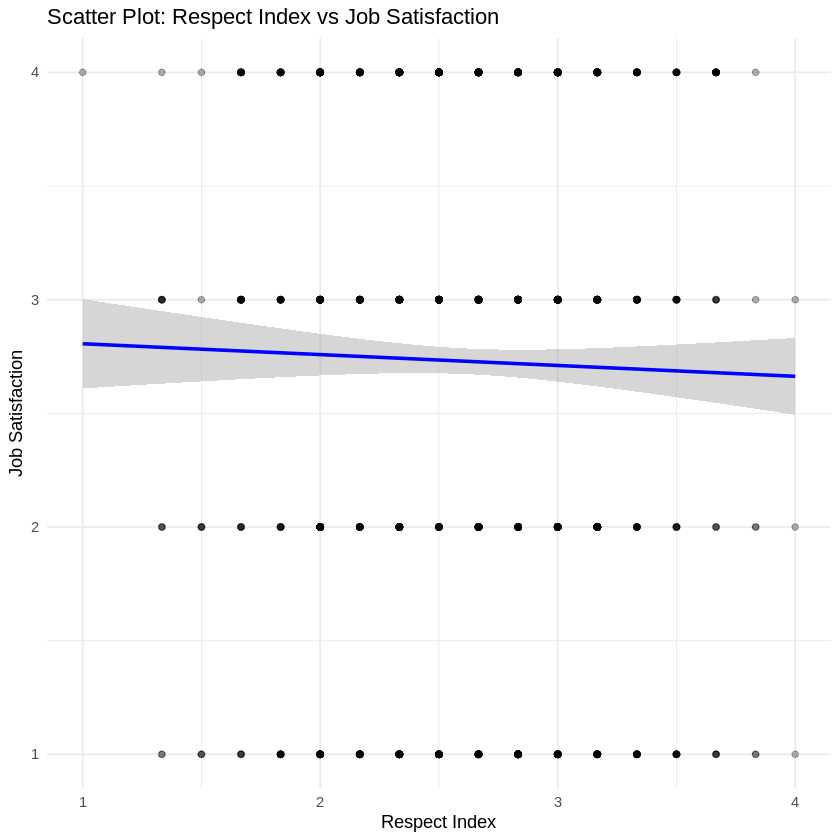

In [13]:
# Scatter plot with regression line

library(ggplot2)
ggplot(df, aes(x = Respect_Index, y = JobSatisfaction)) +
  geom_point(alpha = 0.3) +
  geom_smooth(method = "lm", se = TRUE, color = "blue") +
  labs(title = "Scatter Plot: Respect Index vs Job Satisfaction",
       x = "Respect Index", y = "Job Satisfaction") +
  theme_minimal()

##  **Test 2 - Correlation Matrix & Heatmap**

In [14]:
# Building the matrix

library(corrplot)

cor_vars = df[, c("Respect_Index", "JobSatisfaction", "EnvironmentSatisfaction",
                   "WorkLifeBalance", "RelationshipSatisfaction", "MonthlyIncome")]

cor_matrix = cor(cor_vars, use = "complete.obs")
print(round(cor_matrix, 3))

corrplot 0.95 loaded



                         Respect_Index JobSatisfaction EnvironmentSatisfaction
Respect_Index                    1.000          -0.021                   0.010
JobSatisfaction                 -0.021           1.000                  -0.007
EnvironmentSatisfaction          0.010          -0.007                   1.000
WorkLifeBalance                  0.509          -0.019                   0.028
RelationshipSatisfaction         0.749          -0.012                   0.008
MonthlyIncome                    0.024          -0.007                  -0.006
                         WorkLifeBalance RelationshipSatisfaction MonthlyIncome
Respect_Index                      0.509                    0.749         0.024
JobSatisfaction                   -0.019                   -0.012        -0.007
EnvironmentSatisfaction            0.028                    0.008        -0.006
WorkLifeBalance                    1.000                    0.020         0.031
RelationshipSatisfaction           0.020       

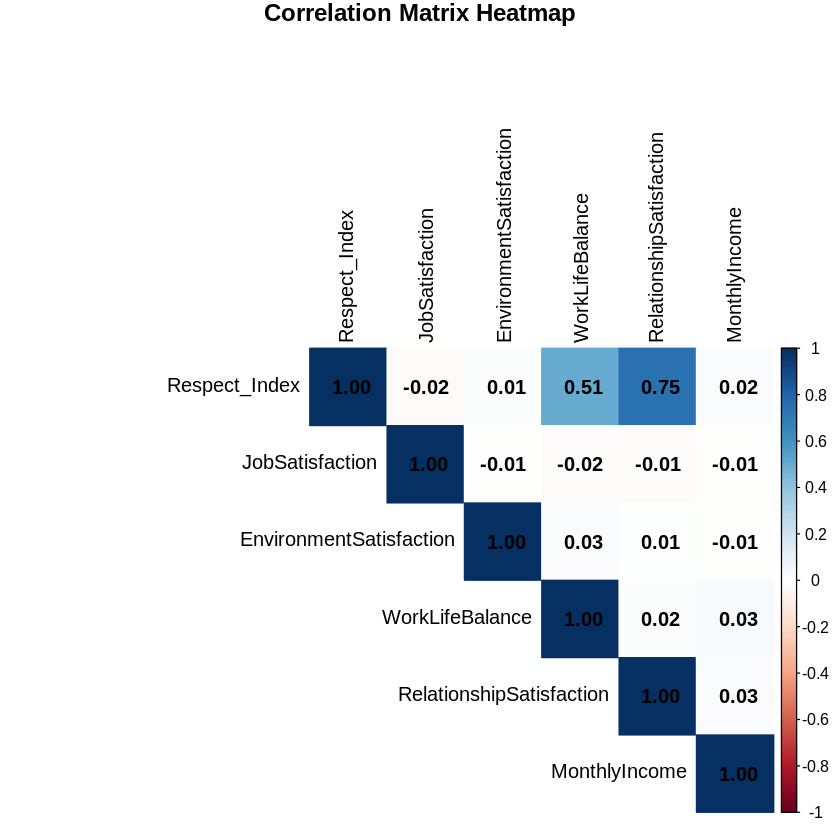

In [15]:
# visualizing the heatmap

corrplot(cor_matrix, method = "color", type = "upper",
         addCoef.col = "black", tl.col = "black",
         title = "Correlation Matrix Heatmap", mar = c(0,0,1,0))

What to comment on:

Which variable pair has the strongest correlation?
Where does Respect_Index sit — is it strongly/weakly related to JobSatisfaction compared to the other variables?

## **Test 3 - Chi-Squared Test**

Testing if there is a significant association between the category of respect (High/Low) and the category of satisfaction (High/Low)



*   H₀: Respect_Category and Satisfaction_Category are independent (no association)

*   H₁: There is a significant association between Respect_Category and Satisfaction_Category



In [16]:
# Build contingency table

ct = table(df$Respect_Category, df$Satisfaction_Category)
print(ct)

      
       High Low
  High  360 256
  Low   541 313


In [17]:
# Check expected frequencies

chisq.test(ct)$expected

# since all expected cells ≥ 5, we proceed with Chi-Square test

,High,Low
High,377.5619,238.4381
Low,523.4381,330.5619


In [22]:
# Chi-Square:
chisq.test(ct)


	Pearson's Chi-squared test with Yates' continuity correction

data:  ct
X-squared = 3.4287, df = 1, p-value = 0.06407


Since the p-value (0.06407) is greater than α = 0.05, we fail to reject H₀. There is insufficient statistical evidence to conclude that Respect_Category and Satisfaction_Category are significantly associated.

In [23]:
# Calculate Cramér's V (effect size)

library(rstatix)
cramer_v(ct)

[1] 0.04829554

# **Test 4 — One-Way ANOVA**
Testing if mean Respect_Index differ significantly across the four levels of JobSatisfaction (1, 2, 3, 4)


*   H₀: Mean Respect_Index is equal across all four JobSatisfaction levels (μ₁ = μ₂ = μ₃ = μ₄)

*   H₁: At least one JobSatisfaction level has a significantly different mean Respect_Index



In [26]:
# Make JobSatisfaction a factor

df$JobSatisfaction_f = as.factor(df$JobSatisfaction)

In [27]:
#  Running Levene's Test first (assumming equal variance)

library(rstatix)
levene_test(df, Respect_Index ~ JobSatisfaction_f)

df1,df2,statistic,p
<int>,<int>,<dbl>,<dbl>
3,1466,0.9003505,0.4403146


 Since p > 0.05, variances are equal. We can proceed with standard ANOVA test.

In [33]:
# Run the ANOVA test

anova_model = aov(Respect_Index ~ JobSatisfaction_f, data = df)
summary(anova_model)

                    Df Sum Sq Mean Sq F value Pr(>F)
JobSatisfaction_f    3    0.2 0.06644   0.279  0.841
Residuals         1466  349.5 0.23843               

In [29]:
# Performing Post-hoc: Fisher's LSD

library(agricolae)
lsd_result <- LSD.test(anova_model, "JobSatisfaction_f", p.adj = "none")
print(lsd_result)

$statistics
    MSerror   Df     Mean       CV
  0.2384262 1466 2.624376 18.60591

$parameters
        test p.ajusted            name.t ntr alpha
  Fisher-LSD      none JobSatisfaction_f   4  0.05

$means
  Respect_Index       std   r         se      LCL      UCL      Min      Max
1      2.636678 0.4901266 289 0.02872288 2.580336 2.693021 1.333333 4.000000
2      2.641071 0.5068622 280 0.02918085 2.583831 2.698312 1.333333 4.000000
3      2.616893 0.4746390 442 0.02322554 2.571334 2.662452 1.333333 4.000000
4      2.613653 0.4885615 459 0.02279138 2.568946 2.658360 1.000000 3.833333
       Q25      Q50 Q75
1 2.333333 2.666667   3
2 2.333333 2.666667   3
3 2.333333 2.666667   3
4 2.333333 2.666667   3

$comparison
NULL

$groups
  Respect_Index groups
2      2.641071      a
1      2.636678      a
3      2.616893      a
4      2.613653      a

attr(,"class")
[1] "group"


**Summary Results Table**

In [32]:
summary_table <- data.frame(
  Test = c("Spearman Correlation", "Chi-Square", "One-Way ANOVA"),
  Variables = c("Respect_Index vs JobSatisfaction",
                "Respect_Category vs Satisfaction_Category",
                "Respect_Index across JobSatisfaction levels"),
  Statistic = c("rho = -0.0259", "X² = 3.4287", "F = 0.279"),
  p_value = c("0.8396", "0.06407", "0.841"),
  Effect_Size = c("rho = -0.0259", "Cramér's V = 0.0482955401914228", "η² = 0.2 / 349.7 = 0.0006"),  # η² = Sum of Squares for JobSatisfaction / SS Total
  Decision = c("Fail to reject H₀", "Fail to reject H₀", "Fail to reject H₀")
)

summary_table

Test,Variables,Statistic,p_value,Effect_Size,Decision
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Spearman Correlation,Respect_Index vs JobSatisfaction,rho = -0.0259,0.8396,rho = -0.0259,Fail to reject H₀
Chi-Square,Respect_Category vs Satisfaction_Category,X² = 3.4287,0.06407,Cramér's V = 0.0482955401914228,Fail to reject H₀
One-Way ANOVA,Respect_Index across JobSatisfaction levels,F = 0.279,0.841,η² = 0.2 / 349.7 = 0.0006,Fail to reject H₀
